# 01. Разведочный анализ данных

Датасет — [MIT Indoor Scenes](https://web.mit.edu/torralba/www/indoor.html), из 67 категорий взяты 5 жилых комнат.
Разбиение на train/val/test (70/15/15, стратифицировано по классам) делается скриптом `python -m src.prepare_data`,
здесь только анализ результата.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

from src.config import CLASSES, PROCESSED_DATA_DIR

SPLITS = ["train", "val", "test"]

## Распределение классов

In [3]:
counts = pd.DataFrame(
    {split: [len(list((PROCESSED_DATA_DIR / split / c).glob("*.jpg"))) for c in CLASSES] for split in SPLITS},
    index=CLASSES,
)
counts.loc["total"] = counts.sum()
counts

,train,val,test
bathroom,137,29,31
bedroom,463,99,100
dining_room,191,41,42
kitchen,513,110,111
livingroom,494,105,107
total,1798,384,391


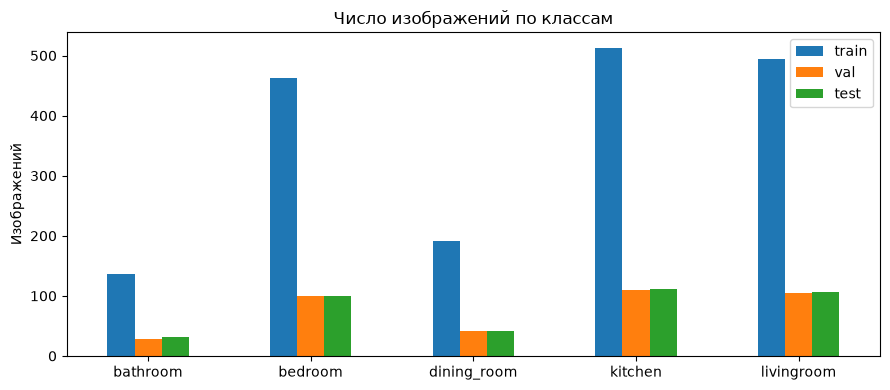

In [4]:
ax = counts.drop("total").plot.bar(figsize=(9, 4), rot=0)
ax.set_title("Число изображений по классам")
ax.set_ylabel("Изображений")
plt.tight_layout()
plt.show()

**Вывод.** Классы несбалансированы: `kitchen` в train почти в 4 раза больше, чем `bathroom` (513 против 137).
Поэтому кроме accuracy смотрим на **macro-F1** — она одинаково взвешивает все классы и не даёт
модели «выехать» на частых кухнях и гостиных.

## Примеры изображений

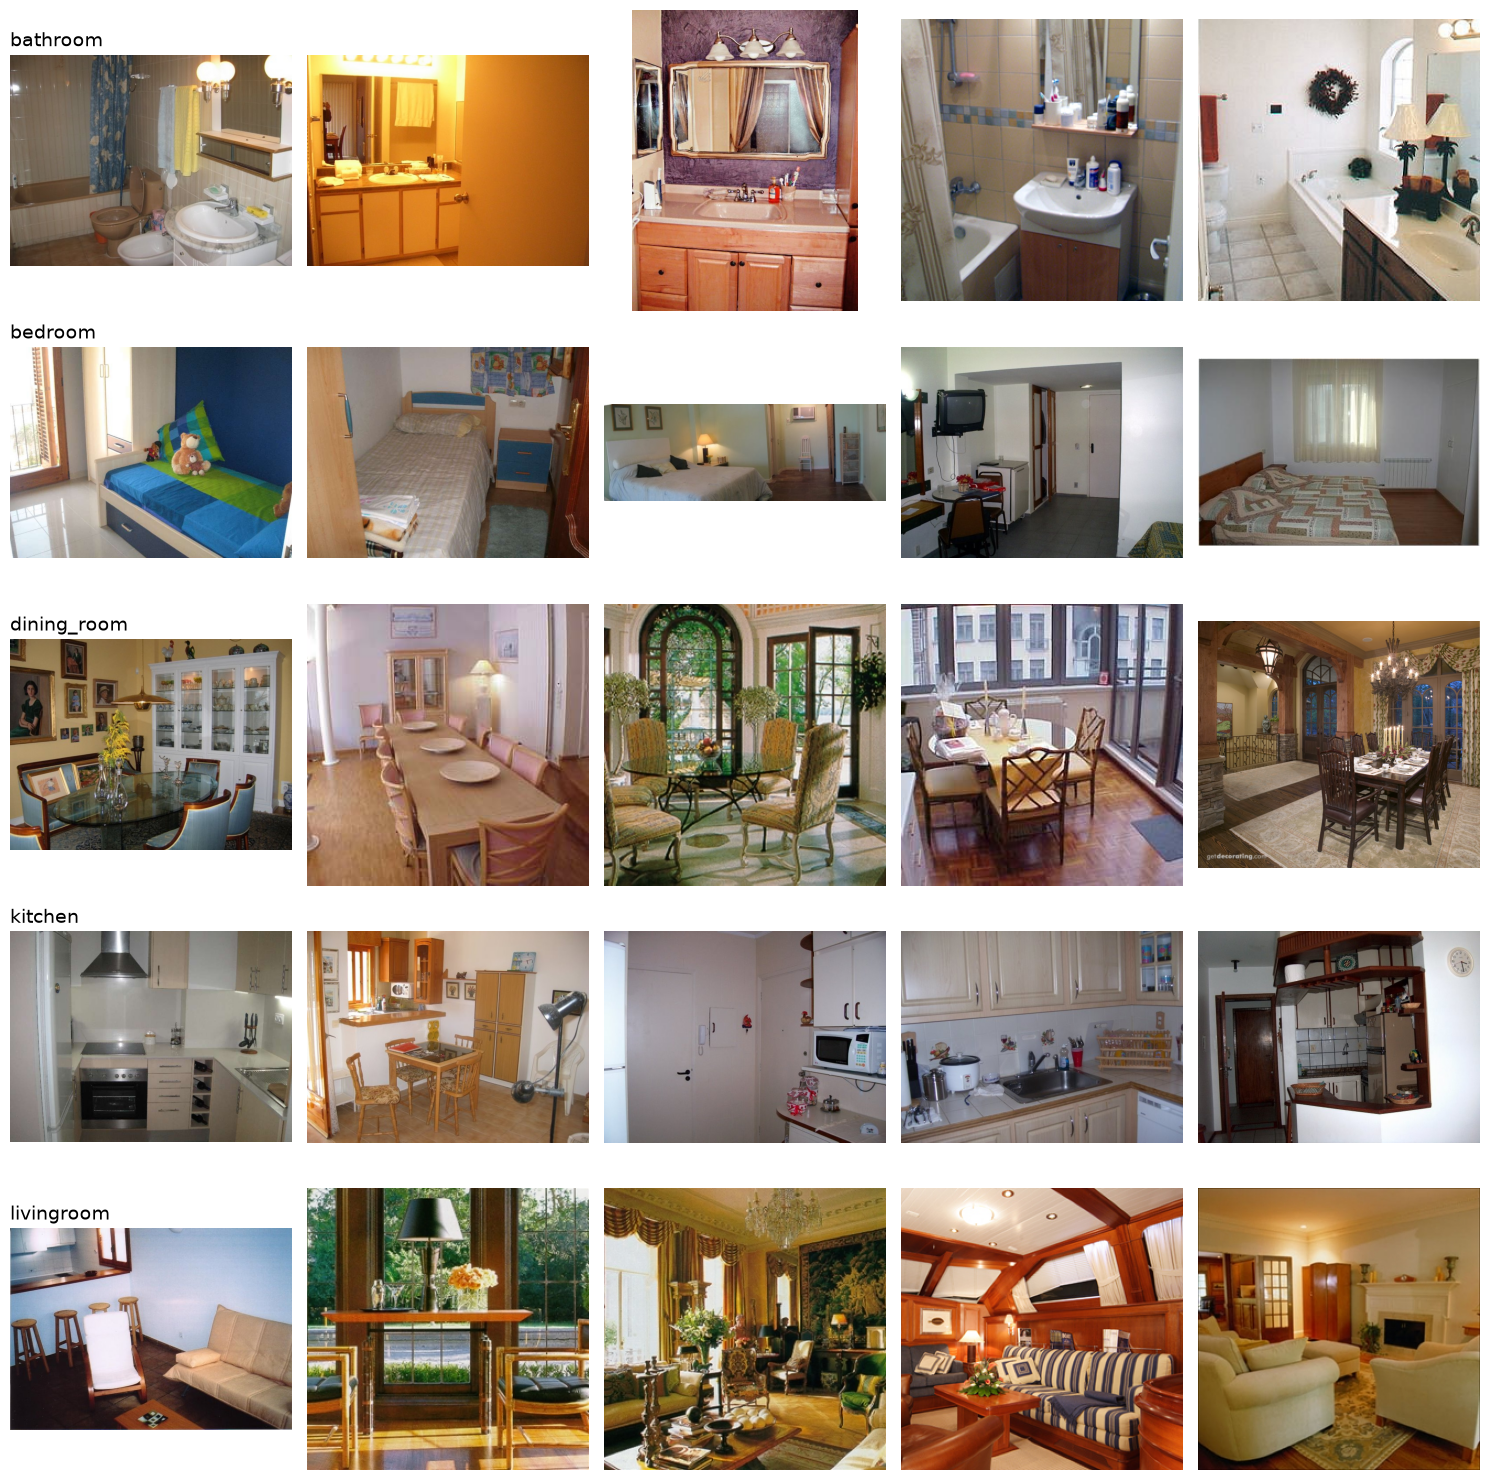

In [5]:
n_per_class = 5
fig, axes = plt.subplots(len(CLASSES), n_per_class, figsize=(3 * n_per_class, 3 * len(CLASSES)))
for row, class_name in zip(axes, CLASSES):
    paths = sorted((PROCESSED_DATA_DIR / "train" / class_name).glob("*.jpg"))[:n_per_class]
    for ax, path in zip(row, paths):
        ax.imshow(Image.open(path).convert("RGB"))
        ax.axis("off")
    row[0].set_title(class_name, loc="left", fontsize=14)
plt.tight_layout()
plt.show()

**Наблюдения.** Ванные и кухни визуально самые «узнаваемые» (сантехника, кухонный гарнитур) — в ноутбуке 02
у них самые высокие F1. Гостиная пересекается с соседними классами по мебели: диван и телевизор встречаются
и в спальнях, обеденный стол — в гостиных с open-space планировкой. Ожидаемо самые трудные пары —
гостиная со спальней и со столовой.

## Размеры и формат изображений

In [6]:
records = []
for split in SPLITS:
    for path in (PROCESSED_DATA_DIR / split).rglob("*.jpg"):
        with Image.open(path) as img:
            records.append({"split": split, "class": path.parent.name,
                            "width": img.width, "height": img.height, "mode": img.mode})
sizes = pd.DataFrame(records)
sizes["aspect"] = sizes["width"] / sizes["height"]
sizes["min_side"] = sizes[["width", "height"]].min(axis=1)

print(sizes["mode"].value_counts().to_string(), "\n")
print("Меньше 224 px по короткой стороне:", (sizes["min_side"] < 224).sum())
sizes[["width", "height", "aspect"]].describe().round(2)

mode
RGB    2567
L         4
P         2 

Меньше 224 px по короткой стороне: 14


,width,height,aspect
count,2573.00,2573.00,2573.00
mean,468.56,424.52,1.07
std,475.17,397.50,0.19
min,200.00,171.00,0.52
25%,256.00,256.00,1.00
50%,256.00,256.00,1.00
75%,450.00,384.00,1.20
max,3264.00,2592.00,2.92


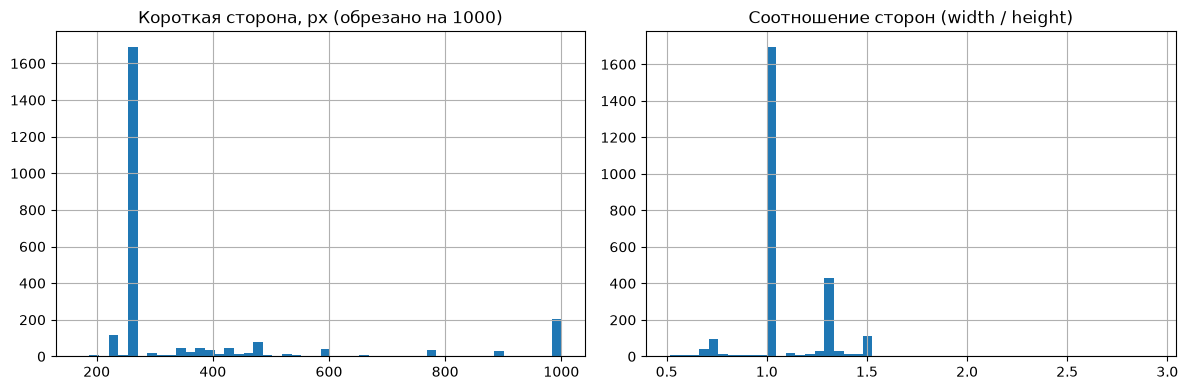

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sizes["min_side"].clip(upper=1000).hist(bins=50, ax=ax1)
ax1.set_title("Короткая сторона, px (обрезано на 1000)")
sizes["aspect"].hist(bins=50, ax=ax2)
ax2.set_title("Соотношение сторон (width / height)")
plt.tight_layout()
plt.show()

**Выводы для препроцессинга.**
- 65% изображений уже ровно 256×256 (1671 из 2573), остальные — от 200 до 3264 px по ширине. Все приводятся к одному виду: `Resize(256)` по короткой стороне +
  `CenterCrop(224)` — стандартный вход ResNet.
- Соотношение сторон в основном 1:1 и 4:3 (пики на 1.0 и ~1.33), крайние значения (0.52–2.92) редки.
  У вытянутых кадров центральный кроп отрезает края, на обучении это частично компенсирует `RandomResizedCrop`.
- 6 изображений не в RGB (4 grayscale `L`, 2 с палитрой `P`) — `ImageFolder` и API конвертируют всё в RGB,
  иначе нормализация на 3 канала упадёт.
- 14 картинок меньше 224 px по короткой стороне — они будут немного апскейлены, на качество это почти не влияет.